# OPTIMAL (TANGENCY) PORTFOLIO  

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import scipy

In [72]:
#number of assets
N = 20
#number of days
T = 2000

#expected returns for all the assets. Assume assets follow GBM so log returns are normal
mu = np.random.uniform(0.0003, 0.0008, N)

#volatilities for all the assets
sigma = np.random.uniform(0.012, 0.02, N)



In [181]:
cov = np.cov(mu, bias=False)

In [182]:
cov

array(2.07640766e-08)

In [73]:
#time series data for all N assets over T days

returns = np.random.normal(
    loc=mu[:, None],
    scale=sigma[:, None],
    size=(N, T)
)

In [157]:

#compute moving returns and covariances
#window 
W = 1000 #want from day 1000 to day 2000(T). Means there are 1001 (Teff) days

T_eff = T - W + 1

mu_roll = np.zeros((T_eff, N))
cov_roll = np.zeros((T_eff, N, N))

for i in range(0,T_eff):
    window = returns[:, i:i+W]

    mu_roll[i] = window.mean(axis=1)
    cov_roll[i] = np.cov(window, bias=False)



In [158]:
len(mu_roll) #helpful to know the length of rolling retuns and covariances

1001

In [159]:

M = 5000   # number of sample portfolios per time slice

#no shorting allowed
weights = np.random.dirichlet(
    alpha=np.ones(N),
    size=M
)


In [160]:
np.sum(weights, axis = 1) #check that all the weights add to 1 for each configuration

array([1., 1., 1., ..., 1., 1., 1.])

In [161]:
#risk-free rate

#annual rate/number of trading days = daily return

r_f = 0.02/252

Equation of Capital Market Line (CML):

$ R_{\Pi} = R_0 + \frac{R - R_0}{\sigma} \sigma_{\Pi} $

Equation of Security Market Line (SML):

$ R_i = R_0 + (R_T - R_0)\frac{\sigma^2(R_i,R_T)}{\sigma_T^2} $

In [162]:
def sig_weight_opt(mu, Sig, m):
    """Minimum-variance weights achieving expected return m."""
    o  = np.ones(len(mu))
    Ci = np.linalg.inv(Sig)
    A  = o @ Ci @ o
    B  = o @ Ci @ mu
    C  = mu @ Ci @ mu
    D = A*C - B**2.

    sig_opt = np.sqrt((A*m**2. - 2*B*m + C) / D)

    weight_opt = np.zeros((len(m), len(mu)))
    for i in range(0, len(m)):
        weight_opt[i] = (1/D)*(( C - B*m[i])*(Ci@o) + (A*m[i] - B)*(Ci@mu))

    return sig_opt, weight_opt
    

In [265]:
def plot_frame(ax, index): #index runs from 0 to T_eff - 1 = 1975

    p1 = ax[0]
    p2 = ax[1]

    #averages and covariance matrices at time t for individual assets
    mu_t = mu_roll[index]
    cov_t = cov_roll[index]
    sigma_t = np.sqrt(np.diagonal(cov_t))

    #all M returns over weight space
    port_mu = weights @ mu_t #this is a vector of portfolios

    #all M volatilities over weight space
    port_var = np.einsum('ij,jk,ik->i', weights, cov_t, weights) #this is a vector of portfolios
    port_sigma = np.sqrt(port_var)

    m = np.linspace(-0.00075, 0.002, 1000)
    sig_opt_t, weight_opt_t = sig_weight_opt(mu_t, cov_t, m )
    max_weight, min_weight = np.max(weight_opt_t), np.min(weight_opt_t)
    #print(np.sum(weight_opt_t, axis = 1)) This is to check weights sum to 1
   
        

    p1.scatter(port_sigma, port_mu, label ='Portfolios, '+r'$\lambda >0$', s= 1)
    p1.scatter(sigma_t, mu_t, label ='Fixed Securities', s=5)
    p1.scatter(sigma, mu, label ='Moving Securities', s=5)

    p1.plot(sig_opt_t, m, label = 'Efficient Frontier', linewidth = 1, c='black', linestyle='dashed')
    p1.annotate(r'$\lambda_{-} = $'+f"{min_weight:.3f}", (0.008, 0.00125))
    p1.annotate(r'$\lambda_{+} = $'+f"{max_weight:.3f}", (0.008, 0.00115))

    
    #CML on going long
    #sharpe ratio
    sharpe = (port_mu - r_f) / port_sigma
    idx = np.argmax(sharpe)

    #tangency portfolio
    mu_T = port_mu[idx]
    sigma_T = port_sigma[idx]
    weights_T = weights[idx,:]

    sigma_line = np.linspace(0, port_sigma.max(), 200)
    cml = r_f + (mu_T - r_f) / sigma_T * sigma_line

    #SML
    sml_var = weights_T @ cov_t
    mu_sml = r_f + (mu_T - r_f)*( sml_var/sigma_T**2)
    
    
    p1.scatter(sigma_T, mu_T, s=15, c='black', label ='tangency portfolio')
    p1.plot(sigma_line, cml, c= 'red', label ='CML, '+r'$\lambda >0$', linestyle='dashed', linewidth=1)
    
    
    p1.legend(loc=3, fontsize=7)
    p1.set_xlabel('Portfolio Risk ' + r'$\sigma_\Pi$', fontsize=15)
    p1.set_ylabel('Portfolio Return ' + r'$R_{\Pi}$', fontsize=15)
    p1.set_xlim([0.003, 0.0225])
    p1.set_ylim([-0.00075, 0.002])

    p2.scatter(mu_t, mu_sml)
    p2.plot(np.sort(mu_t), np.sort(mu_t), c='black', linestyle='dashed')
    p2.set_xlabel('Moving Return 'r'$\mu_t$', fontsize=15)
    p2.set_ylabel('SML Return '+ r'$\mu_{SML}$', fontsize=15)
    p2.set_xlim([-0.00075, 0.002])
    p2.set_ylim([-0.00075, 0.002])

    #plt.show()



    
 
    
    

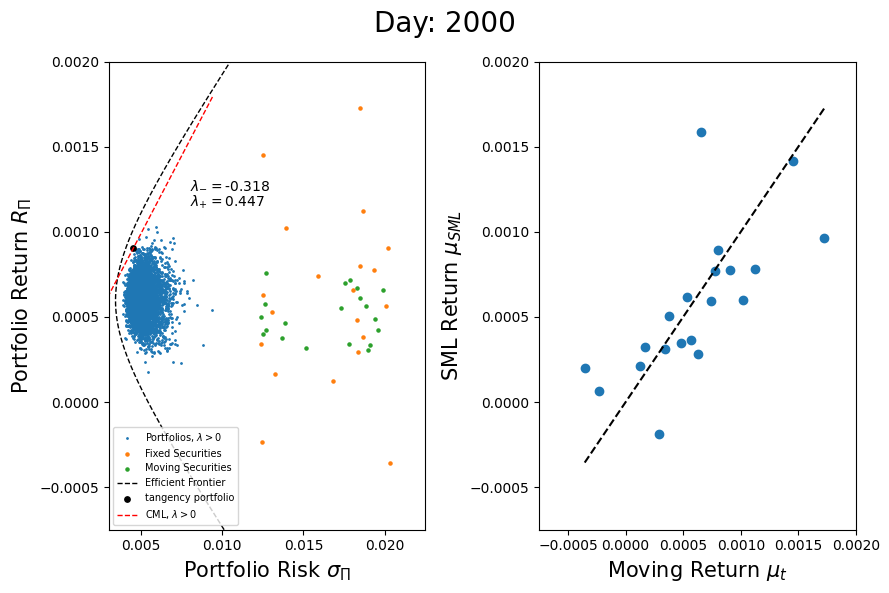

In [266]:
fig, ax  = plt.subplots(1,2, figsize=(9,6), layout = 'tight')

fig.suptitle('Day: '+str(1000 + W), fontsize = 20)
plot_frame(ax, 1000)

## Movie of Optimal Portfolio

In [255]:
#from matplotlib.animation import FFMpegWriter
from matplotlib.animation import PillowWriter

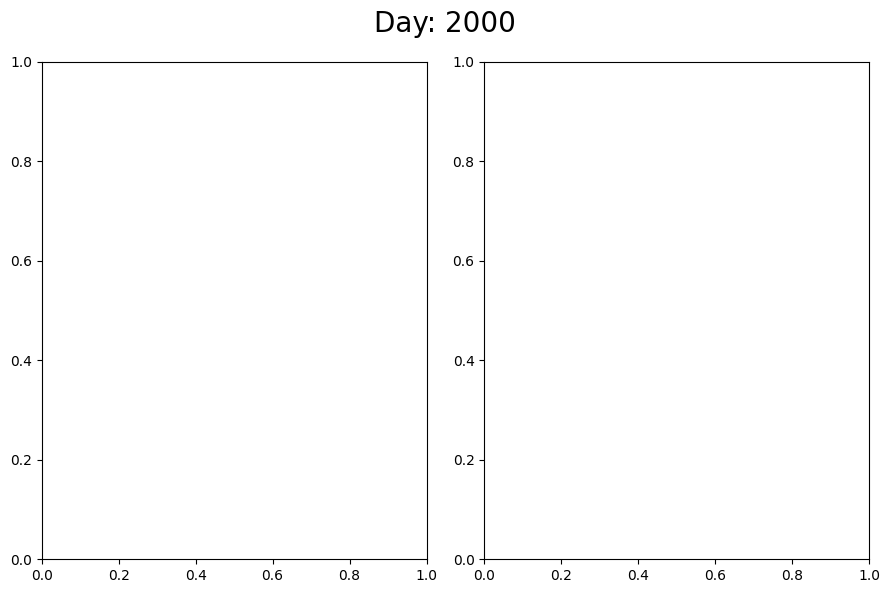

In [267]:
metadata = dict(title='Movie', artist ='ayush_roy')
writer = PillowWriter(fps=10, metadata = metadata)

fig, ax  = plt.subplots(1,2, figsize=(9,6), layout = 'tight')
path = 'portfolio.gif'

with writer.saving(fig, path,100):
    for i in range(0,T_eff):
        if i%4 == 0:
            fig.suptitle('Day: '+str(i + W), fontsize = 20)
            plot_frame(ax, i)
            writer.grab_frame()
            ax[0].cla()
            ax[1].cla()

In [ ]:
def make_movie():
    metadata = dict(title='Movie', artist ='ayush_roy')
    writer = PillowWriter(fps=10, metadata = metadata)

    # Create the figure and subplots
    fig = plt.figure()

    # First row: Single subplot spanning both columns
    ax = plt.subplot()

    path = 'portfolio.mp4'



    with writer.saving(fig, path,100):
        for i in range(0,T_eff):

            #averages and covariance matrices at time t
            mu_t = mu_roll[i]
            cov_t = cov_roll[i]
            sigma_t = np.sqrt(np.diagonal(cov_t))

            #all M returns over weight space
            port_mu = weights @ mu_t

            #all M risks over weight space
            port_var = np.einsum('ij,jk,ik->i', weights, cov_t, weights)
            port_sigma = np.sqrt(port_var)
            
            #CML
            #sharpe ratio
            sharpe = (port_mu - r_f) / port_sigma
            idx = np.argmax(sharpe)

            #tangency portfolio
            mu_T = port_mu[idx]
            sigma_T = port_sigma[idx]


            sigma_line = np.linspace(0, port_sigma.max(), 200)
            cml = r_f + (mu_T - r_f) / sigma_T * sigma_line

            if i%4 == 0:
                ax.scatter(port_sigma, port_mu, label ='portfolios', s= 1)
                ax.scatter(sigma_t, mu_t, label ='moving securities', s=3)
                ax.scatter(sigma, mu, label ='fixed securities',s=3)
                ax.scatter(sigma_T, mu_T, s=15, c='black', label ='tangency portfolio')
                ax.plot(sigma_line, cml, c= 'red', label ='CML', linestyle='dashed', linewidth=1)
                
                ax.set_title('t: '+str(i + W))
                ax.legend(loc=2)
                ax.set_xlabel(r'$\sigma_\Pi$')
                ax.set_ylabel(r'$R_{\Pi}$')
                ax.set_xlim([0.003, 0.0205])
                ax.set_ylim([-0.0005, 0.002])
                writer.grab_frame()
                ax.cla()

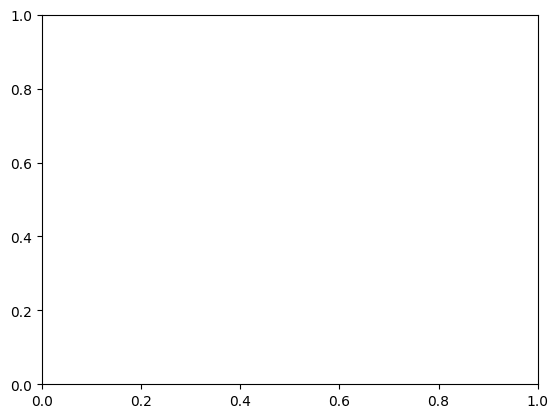

In [14]:
make_movie()